## Experiment Design

Task: learn self-supervised session geometry, then test whether one analyst-confirmed session can steer retrieval of related malicious activity.

Core methods:
- `graph_stats`: handcrafted session statistics from graph-derived sessions.
- `sage_real_full`: HeteroSAGE trained with link prediction on all real typed edges.
- `sage_real_no_host`: the final graph view, with the noisy same-host relation removed.
- `sage_shuffled_no_host`: matched topology control.
- One-anchor cosine retrieval: the explicit few-shot steering experiment.

Defensibility checks:
- Graph-stat feature ablation.
- Real-edge vs shuffled-edge control.
- Malicious-neighbor separation.
- Exhaustive leave-one-anchor-out retrieval over all 19 malicious sessions.
- AP and recall at fixed analyst-review budgets.


# Experiment: ACME4 Telemetry Graph Representation Suite

Objective: turn process telemetry into a heterogeneous graph, learn session embeddings, and test whether malicious sessions become locally coherent and reviewable.

Success criteria:
- Beat label-shuffle controls on top-k review recall.
- Show whether graph structure matters with real-edge vs shuffled-edge controls.
- Show whether temporal node encodings improve grouping.
- Keep all labels out of training; labels are used only for evaluation.


In [1]:
import warnings
import os
import tempfile
from itertools import combinations

os.environ.setdefault("NUMBA_CACHE_DIR", os.path.join(tempfile.gettempdir(), "numba_cache"))

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from sklearn.preprocessing import StandardScaler
from IPython.display import display

warnings.filterwarnings("ignore", message=".*sysctlbyname.*")


In [2]:
SEED = 42
DATA_PATH = "Data/data/ACME4/gold/train-process_uber_summary.parquet"
ROWS = 100_000

RARE_FILE_MIN_DEGREE = 2
RARE_FILE_MAX_DEGREE = 15
SAME_USER_WINDOW = pd.Timedelta(minutes=5)
MAX_SESSION_DURATION = pd.Timedelta(minutes=30)

EPOCHS = 8
HIDDEN = 48
OUT = 48
MAX_POS_PER_EDGE_TYPE = 5_000
K = 15
TOP_FRACTIONS = (0.01, 0.05, 0.10)
EXPERIMENT_SEEDS = (42, 43, 44)

np.random.seed(SEED)
torch.manual_seed(SEED)

## Data Slice

Use the late ACME4 time slice so the experiment is chronological and reproducible. The dataset is sorted by `process_started`, deduplicated by `pid_hash`, and sliced from the tail.


In [3]:
def load_acme_slice(path=DATA_PATH, rows=ROWS):
    df = pd.read_parquet(path)
    df = df.copy()
    df["_time"] = pd.to_datetime(df["process_started"], errors="coerce", utc=True)
    df = (
        df[df["_time"].notna()]
        .sort_values("_time")
        .drop_duplicates("pid_hash", keep="first")
        .tail(rows)
        .reset_index(drop=True)
    )
    return df

late_df = load_acme_slice()

summary = pd.DataFrame([{
    "rows": len(late_df),
    "processes": late_df["pid_hash"].nunique(),
    "red_process_rows": int(late_df["red_team"].fillna(0).astype(int).sum()),
    "start": late_df["_time"].min(),
    "end": late_df["_time"].max(),
}])

display(summary)


,rows,processes,red_process_rows,start,end
0,100000,100000,31,2024-09-18 20:45:15.961034+00:00,2024-09-22 23:57:33.487951+00:00


## Graph Builder

The graph keeps process, file, parent-child, and temporal relations. Known users receive `same_user_time_window` edges; rows without a user receive the distinct `same_host_time_window` fallback. Evaluation sessions use the same identity rule and split after five minutes of inactivity or 30 minutes total duration, preventing transitive multi-day components.

In [4]:
class ACMETelemetryGraphBuilder:
    FEATURE_COLS = [
        "duration_seconds",
        "num_uniq_file_hash",
        "net_total_events",
        "conn_id_count",
        "reg_totals",
    ]

    FEATURE_NAMES = [
        "duration",
        "num_file_hash",
        "net_events",
        "conn_id_count",
        "reg_totals",
    ]

    def __init__(
        self,
        rare_file_min_degree=RARE_FILE_MIN_DEGREE,
        rare_file_max_degree=RARE_FILE_MAX_DEGREE,
        same_user_window=SAME_USER_WINDOW,
        max_session_duration=MAX_SESSION_DURATION,
    ):
        self.rare_file_min_degree = rare_file_min_degree
        self.rare_file_max_degree = rare_file_max_degree
        self.same_user_window = same_user_window
        self.max_session_duration = max_session_duration

    def build(self, df):
        self.df = df.copy().reset_index(drop=True)
        self.df["process_started"] = pd.to_datetime(self.df["process_started"], errors="coerce", utc=True)
        self.process_ids = self.df["pid_hash"].tolist()
        self.node_index = {pid: i for i, pid in enumerate(self.process_ids)}
        self.file_index = {}
        self.parent_child_edges = []
        self.same_user_edges = []
        self.same_host_edges = []
        self.touches_edges = []
        self.file_to_processes = {}

        self._add_parent_child_edges()
        self._add_same_user_edges()
        self._add_same_host_edges()
        self._add_file_edges()

        data = self._to_heterodata()
        self.sessions = self._extract_bounded_sessions()
        data["process"].session_id = self._session_id_tensor(len(self.process_ids), self.sessions)
        return data

    def _process_features(self):
        X = self.df[self.FEATURE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=np.float32)
        return torch.tensor(X, dtype=torch.float)

    def _process_labels(self):
        y = pd.to_numeric(self.df["red_team"], errors="coerce").fillna(0).astype(int).to_numpy()
        return torch.tensor(y, dtype=torch.long)

    def _add_parent_child_edges(self):
        for row in self.df.itertuples(index=False):
            parent = getattr(row, "parent_pid_hash")
            child = getattr(row, "pid_hash")
            if pd.notna(parent) and parent in self.node_index and child in self.node_index:
                self.parent_child_edges.append((self.node_index[parent], self.node_index[child]))

    def _add_same_user_edges(self):
        valid = self.df["user_name"].notna() & self.df["hostname"].notna()
        for _, group in self.df.loc[valid].groupby(["user_name", "hostname"], dropna=False):
            group = group.sort_values("process_started")
            pids = group["pid_hash"].to_numpy()
            times = group["process_started"].to_numpy()
            for i in range(len(group)):
                src = self.node_index.get(pids[i])
                if src is None:
                    continue
                for j in range(i + 1, len(group)):
                    if times[j] - times[i] > self.same_user_window:
                        break
                    dst = self.node_index.get(pids[j])
                    if dst is not None:
                        self.same_user_edges.append((src, dst))

    def _add_same_host_edges(self):
        valid = self.df["user_name"].isna() & self.df["hostname"].notna()
        for _, group in self.df.loc[valid].groupby("hostname", dropna=False):
            group = group.sort_values("process_started")
            pids = group["pid_hash"].to_numpy()
            times = group["process_started"].to_numpy()
            for i in range(len(group)):
                src = self.node_index.get(pids[i])
                if src is None:
                    continue
                for j in range(i + 1, len(group)):
                    if times[j] - times[i] > self.same_user_window:
                        break
                    dst = self.node_index.get(pids[j])
                    if dst is not None:
                        self.same_host_edges.append((src, dst))


    def _add_file_edges(self):
        file_counts = self.df["filename"].dropna().value_counts()
        rare_files = set(file_counts[
            (file_counts >= self.rare_file_min_degree) &
            (file_counts <= self.rare_file_max_degree)
        ].index)

        for row in self.df.itertuples(index=False):
            fname = getattr(row, "filename")
            pid = getattr(row, "pid_hash")
            if pd.isna(fname) or fname not in rare_files or pid not in self.node_index:
                continue
            if fname not in self.file_index:
                self.file_index[fname] = len(self.file_index)
            pidx = self.node_index[pid]
            fidx = self.file_index[fname]
            self.touches_edges.append((pidx, fidx))
            self.file_to_processes.setdefault(fname, []).append(pidx)

    def _edge_tensor(self, edges):
        return torch.tensor(edges, dtype=torch.long).t().contiguous()

    def _to_heterodata(self):
        data = HeteroData()
        data["process"].x = self._process_features()
        data["process"].y = self._process_labels()
        data["file"].x = torch.ones((len(self.file_index), 1), dtype=torch.float)

        if self.parent_child_edges:
            data["process", "parent_child", "process"].edge_index = self._edge_tensor(self.parent_child_edges)
        if self.same_user_edges:
            data["process", "same_user_time_window", "process"].edge_index = self._edge_tensor(self.same_user_edges)
        if self.same_host_edges:
            data["process", "same_host_time_window", "process"].edge_index = self._edge_tensor(self.same_host_edges)
        if self.touches_edges:
            ei = self._edge_tensor(self.touches_edges)
            data["process", "touches", "file"].edge_index = ei
            data["file", "touched_by", "process"].edge_index = ei.flip(0)
        return data

    def _extract_bounded_sessions(self):
        work = self.df[["hostname", "user_name", "process_started"]].copy()
        work["node_id"] = np.arange(len(work))
        work["session_host"] = work["hostname"]
        missing_host = work["session_host"].isna()
        work.loc[missing_host, "session_host"] = (
            "__missing_host_" + work.loc[missing_host, "node_id"].astype(str)
        )
        work["session_identity"] = work["user_name"].fillna("__host_activity__")
        work = work.sort_values(
            ["session_host", "session_identity", "process_started"],
            kind="mergesort",
        )

        sessions = []
        grouped = work.groupby(
            ["session_host", "session_identity"],
            sort=False,
            dropna=False,
        )
        for _, group in grouped:
            current = []
            session_start = None
            previous_time = None

            for event_time, node_id in group[["process_started", "node_id"]].itertuples(
                index=False,
                name=None,
            ):
                should_split = current and (
                    event_time - previous_time > self.same_user_window
                    or event_time - session_start > self.max_session_duration
                )
                if should_split:
                    sessions.append(current)
                    current = []
                    session_start = None

                if not current:
                    session_start = event_time
                current.append(int(node_id))
                previous_time = event_time

            if current:
                sessions.append(current)

        return sorted(sessions, key=lambda session: session[0])


    def _session_id_tensor(self, n_processes, sessions):
        ids = np.empty(n_processes, dtype=np.int64)
        for sid, session in enumerate(sessions):
            ids[session] = sid
        return torch.tensor(ids, dtype=torch.long)


builder = ACMETelemetryGraphBuilder()
graph_data = builder.build(late_df)
sessions = builder.sessions
process_df = late_df.set_index("pid_hash").reindex(builder.process_ids).reset_index()

session_sizes = np.asarray([len(session) for session in sessions])
session_spans = np.asarray([
    (
        process_df.loc[session, "_time"].max()
        - process_df.loc[session, "_time"].min()
    ).total_seconds() / 60.0
    for session in sessions
])

session_sizes = np.asarray([len(session) for session in sessions])
session_spans = np.asarray([
    (
        process_df.loc[session, "_time"].max()
        - process_df.loc[session, "_time"].min()
    ).total_seconds() / 60.0
    for session in sessions
])

build_summary = pd.DataFrame([{
    "process_nodes": graph_data["process"].num_nodes,
    "file_nodes": graph_data["file"].num_nodes,
    "edge_types": len(graph_data.edge_types),
    "sessions": len(sessions),
    "malicious_sessions": int(sum(any(graph_data["process"].y[n].item() == 1 for n in s) for s in sessions)),
    "median_session_size": float(np.median(session_sizes)),
    "p95_session_size": float(np.quantile(session_sizes, 0.95)),
    "max_session_size": int(session_sizes.max()),
    "p95_session_minutes": float(np.quantile(session_spans, 0.95)),
    "max_session_minutes": float(session_spans.max()),
    "parent_child_edges": len(builder.parent_child_edges),
    "same_user_edges": len(builder.same_user_edges),
    "same_host_edges": len(builder.same_host_edges),
    "touches_edges": len(builder.touches_edges),
}])

display(build_summary)

,process_nodes,file_nodes,edge_types,sessions,malicious_sessions,median_session_size,p95_session_size,max_session_size,p95_session_minutes,max_session_minutes,parent_child_edges,same_user_edges,same_host_edges,touches_edges
0,100000,14,5,3131,19,2.0,137.0,213,29.998144,29.999997,2318,42127,1389585,66


## Evaluation Helpers

The target is malicious session grouping, not supervised classification. Metrics therefore focus on local malicious-neighbor coherence and analyst review recall from unsupervised scores.


In [5]:
def session_labels(data, sessions):
    labels = []
    for session in sessions:
        is_malicious = any(data["process"].y[n].item() == 1 for n in session)
        labels.append("malicious" if is_malicious else "benign")
    return np.asarray(labels)


def knn_scores_and_neighbor_rate(X, labels, k=K):
    X = np.asarray(X, dtype=np.float32)
    y = (np.asarray(labels) == "malicious").astype(int)
    qk = min(k + 1, len(X))
    tree = cKDTree(X)
    dists, idx = tree.query(X, k=qk, workers=-1)
    if qk == 1:
        neighbor_idx = idx[:, None]
        neighbor_dists = dists[:, None]
    else:
        neighbor_idx = idx[:, 1:]
        neighbor_dists = dists[:, 1:]
    neighbor_rate = y[neighbor_idx].mean(axis=1)
    scores = neighbor_dists.mean(axis=1)
    return scores, neighbor_rate


def top_recall_from_scores(scores, labels, fractions=TOP_FRACTIONS):
    y = (np.asarray(labels) == "malicious").astype(int)
    order = np.argsort(scores)[::-1]
    total = int(y.sum())
    rows = []
    for frac in fractions:
        n = max(1, int(np.ceil(len(y) * frac)))
        hits = int(y[order[:n]].sum())
        rows.append({
            "top_fraction": frac,
            "reviewed_sessions": n,
            "malicious_found": hits,
            "total_malicious": total,
            "recall": hits / total if total else np.nan,
            "precision": hits / n,
            "lift": (hits / n) / (total / len(y)) if total else np.nan,
        })
    return pd.DataFrame(rows)


def evaluate_embedding(name, X, labels):
    scores, neighbor_rate = knn_scores_and_neighbor_rate(X, labels)
    y = (np.asarray(labels) == "malicious").astype(int)
    q = top_recall_from_scores(scores, labels)
    row = {
        "method": name,
        "n_sessions": len(y),
        "malicious_sessions": int(y.sum()),
        "mal_neighbor_rate": neighbor_rate[y == 1].mean(),
        "ben_neighbor_rate": neighbor_rate[y == 0].mean(),
        "separation_gap": neighbor_rate[y == 1].mean() - neighbor_rate[y == 0].mean(),
    }
    for _, r in q.iterrows():
        pct = int(r["top_fraction"] * 100)
        row[f"top{pct}_found"] = int(r["malicious_found"])
        row[f"top{pct}_recall"] = r["recall"]
    return row


def label_shuffle_control(X, labels, repeats=50, seed=SEED):
    scores, _ = knn_scores_and_neighbor_rate(X, labels)
    y = np.asarray(labels)
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(repeats):
        shuffled = rng.permutation(y)
        q = top_recall_from_scores(scores, shuffled)
        rows.append({
            "top1_recall": q.loc[q["top_fraction"] == 0.01, "recall"].iloc[0],
            "top5_recall": q.loc[q["top_fraction"] == 0.05, "recall"].iloc[0],
            "top10_recall": q.loc[q["top_fraction"] == 0.10, "recall"].iloc[0],
        })
    out = pd.DataFrame(rows).mean(numeric_only=True).to_frame().T
    out.insert(0, "control", "label_shuffle_mean")
    return out


## Baseline: Graph-Derived Session Statistics

This baseline is intentionally simple: aggregate process-node telemetry within each graph-derived session and append basic structure counts. It is the minimum bar every learned embedding should beat.


In [6]:
GRAPH_STAT_NAMES = [
    "duration_mean", "num_file_hash_mean", "net_events_mean", "conn_id_mean", "reg_totals_mean",
    "duration_std", "num_file_hash_std", "net_events_std", "conn_id_std", "reg_totals_std",
    "session_size", "parent_child_edges", "touches_edges", "same_user_edges", "same_host_edges",
]


def embed_graph_stats(data, sessions):
    n_sessions = len(sessions)
    node_to_session = {}
    for sid, session in enumerate(sessions):
        for node in session:
            node_to_session[node] = sid

    parent_counts = np.zeros(n_sessions, dtype=np.float32)
    touches_counts = np.zeros(n_sessions, dtype=np.float32)
    same_user_counts = np.zeros(n_sessions, dtype=np.float32)
    same_host_counts = np.zeros(n_sessions, dtype=np.float32)

    if ("process", "parent_child", "process") in data.edge_types:
        for u, v in data["process", "parent_child", "process"].edge_index.t().tolist():
            if node_to_session.get(u) == node_to_session.get(v):
                parent_counts[node_to_session[u]] += 1

    if ("process", "touches", "file") in data.edge_types:
        for u, _ in data["process", "touches", "file"].edge_index.t().tolist():
            if u in node_to_session:
                touches_counts[node_to_session[u]] += 1

    if ("process", "same_user_time_window", "process") in data.edge_types:
        for u, v in data["process", "same_user_time_window", "process"].edge_index.t().tolist():
            if node_to_session.get(u) == node_to_session.get(v):
                same_user_counts[node_to_session[u]] += 1

    if ("process", "same_host_time_window", "process") in data.edge_types:
        for u, v in data["process", "same_host_time_window", "process"].edge_index.t().tolist():
            if node_to_session.get(u) == node_to_session.get(v):
                same_host_counts[node_to_session[u]] += 1


    rows = []
    for sid, session in enumerate(sessions):
        feats = data["process"].x[session]
        mean = feats.mean(dim=0).numpy()
        std = feats.std(dim=0, unbiased=False).numpy()
        rows.append(np.concatenate([
            mean,
            std,
            [
                len(session),
                parent_counts[sid],
                touches_counts[sid],
                same_user_counts[sid],
                same_host_counts[sid],
            ],
        ]))

    return np.asarray(rows, dtype=np.float32)


labels_eval = session_labels(graph_data, sessions)
X_graph_stats_raw = embed_graph_stats(graph_data, sessions)
X_graph_stats = StandardScaler().fit_transform(np.nan_to_num(X_graph_stats_raw))
X_node_stats = StandardScaler().fit_transform(np.nan_to_num(X_graph_stats_raw[:, :10]))

baseline_row = evaluate_embedding("graph_stats", X_graph_stats, labels_eval)
display(pd.DataFrame([baseline_row]))

,method,n_sessions,malicious_sessions,mal_neighbor_rate,ben_neighbor_rate,separation_gap,top1_found,top1_recall,top5_found,top5_recall,top10_found,top10_recall
0,graph_stats,3131,19,0.161404,0.005249,0.156155,0,0.0,1,0.052632,5,0.263158


## Graph-Stat Ablation

This tests what part of the graph-stat baseline is actually carrying signal: node telemetry, session size, or edge counts.


In [7]:
ABLATION_GROUPS = {
    "all_graph_stats": np.arange(X_graph_stats_raw.shape[1]),
    "node_means_only": np.arange(0, 5),
    "node_stds_only": np.arange(5, 10),
    "node_stats_only": np.arange(0, 10),
    "session_size_only": np.array([10]),
    "edge_counts_only": np.array([11, 12, 13, 14]),
    "structure_only": np.array([10, 11, 12, 13, 14]),
}

ablation = []
for name, cols in ABLATION_GROUPS.items():
    X = StandardScaler().fit_transform(np.nan_to_num(X_graph_stats_raw[:, cols]))
    ablation.append(evaluate_embedding(name, X, labels_eval))

ablation = pd.DataFrame(ablation).sort_values(
    ["top5_recall", "top1_recall", "separation_gap"],
    ascending=False,
)

display(ablation[[
    "method", "separation_gap",
    "top1_found", "top1_recall",
    "top5_found", "top5_recall",
    "top10_found", "top10_recall",
]])

display(label_shuffle_control(X_graph_stats, labels_eval))

,method,separation_gap,top1_found,top1_recall,top5_found,top5_recall,top10_found,top10_recall
3,node_stats_only,0.156305,0,0.0,5,0.263158,14,0.736842
1,node_means_only,0.138226,0,0.0,4,0.210526,14,0.736842
2,node_stds_only,0.091502,0,0.0,3,0.157895,12,0.631579
0,all_graph_stats,0.156155,0,0.0,1,0.052632,5,0.263158
6,structure_only,0.165036,0,0.0,0,0.000000,0,0.000000
5,edge_counts_only,0.164865,0,0.0,0,0.000000,0,0.000000
4,session_size_only,0.000000,0,0.0,0,0.000000,0,0.000000


,control,top1_recall,top5_recall,top10_recall
0,label_shuffle_mean,0.007368,0.045263,0.091579


## Self-Supervised Heterogeneous Graph Learning

Training task: typed link prediction. The model learns node embeddings that score real graph edges higher than randomly sampled fake edges. Labels are not used during training.

The final encoder excludes the dominant `same_host_time_window` relation after ablation showed that it diluted malicious-session coherence. Process labels are never used in link-prediction training.


In [ ]:
def make_x_dict(data):
    x_dict = {}
    for ntype in data.node_types:
        x = data[ntype].x.float()
        if ntype == "process":
            x = torch.tensor(
                StandardScaler().fit_transform(x.cpu().numpy()),
                dtype=torch.float,
            )
        x_dict[ntype] = x
    return x_dict


def base_edge_dict(data):
    return {et: data[et].edge_index for et in data.edge_types}


def add_reverse_edges(edge_dict):
    out = dict(edge_dict)
    for src, rel, dst in list(edge_dict.keys()):
        ei = edge_dict[(src, rel, dst)]
        if src == dst:
            out[(dst, f"rev_{rel}", src)] = ei.flip(0)
        else:
            has_reverse = any(et[0] == dst and et[2] == src for et in out)
            if not has_reverse:
                out[(dst, f"rev_{rel}", src)] = ei.flip(0)
    return out


def shuffled_base_edge_dict(data, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    out = {}
    for et in data.edge_types:
        ei = data[et].edge_index
        if ei.shape[1] <= 1:
            out[et] = ei.clone()
            continue
        perm = torch.randperm(ei.shape[1], generator=g)
        out[et] = torch.stack([ei[0].clone(), ei[1, perm].clone()], dim=0)
    return out


class SmallHeteroSAGE(nn.Module):
    def __init__(self, edge_types, hidden=HIDDEN, out=OUT):
        super().__init__()
        self.convs = nn.ModuleList([
            HeteroConv({et: SAGEConv((-1, -1), hidden) for et in edge_types}, aggr="sum"),
            HeteroConv({et: SAGEConv((-1, -1), out) for et in edge_types}, aggr="sum"),
        ])

    def forward(self, x_dict, edge_index_dict):
        z = self.convs[0](x_dict, edge_index_dict)
        z = {k: F.relu(v) for k, v in z.items()}
        return self.convs[1](z, edge_index_dict)


def score_edges(z_src, z_dst, edge_index):
    src, dst = edge_index
    return 5.0 * F.cosine_similarity(z_src[src], z_dst[dst], dim=1)


def negative_edges(num_src, num_dst, n_edges, generator):

    return torch.stack([

        torch.randint(0, num_src, (n_edges,), generator=generator),

        torch.randint(0, num_dst, (n_edges,), generator=generator),

    ], dim=0)



def train_sage(name, edge_index_dict, x_dict, seed):

    torch.manual_seed(seed)

    generator = torch.Generator().manual_seed(seed + 10_000)

    model = SmallHeteroSAGE(list(edge_index_dict.keys()))
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(EPOCHS):
        model.train()
        opt.zero_grad()
        z = model(x_dict, edge_index_dict)
        losses = []

        for et in graph_data.edge_types:
            if et not in edge_index_dict:
                continue
            src_type, _, dst_type = et
            pos_edge = edge_index_dict[et]
            n_pos = min(MAX_POS_PER_EDGE_TYPE, pos_edge.shape[1])
            if n_pos == 0:
                continue

            perm = torch.randperm(pos_edge.shape[1], generator=generator)[:n_pos]
            pos_edge = pos_edge[:, perm]
            neg_edge = negative_edges(
                graph_data[src_type].num_nodes,
                graph_data[dst_type].num_nodes,
                n_pos,
                generator,
            )

            pos_score = score_edges(z[src_type], z[dst_type], pos_edge)
            neg_score = score_edges(z[src_type], z[dst_type], neg_edge)
            losses.append(
                F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score)) +
                F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
            )

        loss = torch.stack(losses).mean()
        loss.backward()
        opt.step()

        if epoch in {0, EPOCHS - 1}:
            print(f"{name} epoch={epoch:02d} loss={loss.detach().item():.4f}")

    model.eval()
    with torch.no_grad():
        z = model(x_dict, edge_index_dict)
    return z


def mean_pool_sessions(process_embeddings, sessions):
    return np.vstack([process_embeddings[s].mean(axis=0) for s in sessions])


def session_embedding_from_z(z, sessions):
    X = mean_pool_sessions(z["process"].cpu().numpy(), sessions)
    return StandardScaler().fit_transform(np.nan_to_num(X))

## Core Experiment Suite

Each learned method is trained with three fixed random seeds. Reported means and standard deviations therefore capture basic optimization variability instead of relying on one favorable run.

In [9]:
real_edges = add_reverse_edges(base_edge_dict(graph_data))
real_edges_no_host = {
    et: ei for et, ei in real_edges.items()
    if "same_host_time_window" not in et[1]
}
x_dict = make_x_dict(graph_data)

run_rows = []
sage_real_no_host_by_seed = {}
sage_shuffled_no_host_by_seed = {}
for seed in EXPERIMENT_SEEDS:
    shuffled_edges = add_reverse_edges(shuffled_base_edge_dict(graph_data, seed=seed))
    shuffled_edges_no_host = {
        et: ei for et, ei in shuffled_edges.items()
        if "same_host_time_window" not in et[1]
    }

    z_sage_full = train_sage(
        f"sage_real_full seed={seed}",
        real_edges,
        x_dict,
        seed,
    )
    z_sage_real_no_host = train_sage(
        f"sage_real_no_host seed={seed}",
        real_edges_no_host,
        x_dict,
        seed,
    )
    z_sage_shuffled_no_host = train_sage(
        f"sage_shuffled_no_host seed={seed}",
        shuffled_edges_no_host,
        x_dict,
        seed,
    )
    sage_real_no_host_by_seed[seed] = session_embedding_from_z(z_sage_real_no_host, sessions)
    sage_shuffled_no_host_by_seed[seed] = session_embedding_from_z(z_sage_shuffled_no_host, sessions)
    method_embeddings = {
        "graph_stats": X_graph_stats,
        "node_stats_baseline": X_node_stats,
        "sage_real_full": session_embedding_from_z(z_sage_full, sessions),
        "sage_real_no_host": sage_real_no_host_by_seed[seed],
        "sage_shuffled_no_host": sage_shuffled_no_host_by_seed[seed],
    }

    for method, embedding in method_embeddings.items():
        row = evaluate_embedding(method, embedding, labels_eval)
        row["seed"] = seed
        run_rows.append(row)

comparison_runs = pd.DataFrame(run_rows)
metric_cols = [
    "separation_gap",
    "top1_recall",
    "top5_recall",
    "top10_recall",
]
comparison = comparison_runs.groupby("method")[metric_cols].agg(["mean", "std"])
comparison.columns = [f"{metric}_{stat}" for metric, stat in comparison.columns]
comparison = comparison.reset_index().sort_values(
    ["separation_gap_mean", "top10_recall_mean"],
    ascending=False,
)

display(comparison)
display(
    comparison_runs[
        ["method", "seed", "separation_gap", "top1_recall", "top5_recall", "top10_recall"]
    ].sort_values(["method", "seed"])
)

sage_real_full seed=42 epoch=00 loss=2.5716
sage_real_full seed=42 epoch=07 loss=1.6276
sage_real_no_host seed=42 epoch=00 loss=2.5323
sage_real_no_host seed=42 epoch=07 loss=1.4099
sage_shuffled_no_host seed=42 epoch=00 loss=2.5905
sage_shuffled_no_host seed=42 epoch=07 loss=1.4743
sage_real_full seed=43 epoch=00 loss=2.9363
sage_real_full seed=43 epoch=07 loss=1.6637
sage_real_no_host seed=43 epoch=00 loss=2.5864
sage_real_no_host seed=43 epoch=07 loss=1.4985
sage_shuffled_no_host seed=43 epoch=00 loss=2.5675
sage_shuffled_no_host seed=43 epoch=07 loss=1.5025
sage_real_full seed=44 epoch=00 loss=2.7722
sage_real_full seed=44 epoch=07 loss=1.6401
sage_real_no_host seed=44 epoch=00 loss=2.4599
sage_real_no_host seed=44 epoch=07 loss=1.4767
sage_shuffled_no_host seed=44 epoch=00 loss=2.7878
sage_shuffled_no_host seed=44 epoch=07 loss=1.5947


,method,separation_gap_mean,separation_gap_std,top1_recall_mean,top1_recall_std,top5_recall_mean,top5_recall_std,top10_recall_mean,top10_recall_std
3,sage_real_no_host,0.194779,0.018960,0.000000,0.000000,0.000000,0.000000,0.315789,0.105263
2,sage_real_full,0.175624,0.010663,0.000000,0.000000,0.000000,0.000000,0.192982,0.030387
1,node_stats_baseline,0.156305,0.000000,0.000000,0.000000,0.263158,0.000000,0.736842,0.000000
0,graph_stats,0.156155,0.000000,0.000000,0.000000,0.052632,0.000000,0.263158,0.000000
4,sage_shuffled_no_host,0.052019,0.023264,0.105263,0.052632,0.228070,0.060774,0.333333,0.121547


,method,seed,separation_gap,top1_recall,top5_recall,top10_recall
0,graph_stats,42,0.156155,0.000000,0.052632,0.263158
5,graph_stats,43,0.156155,0.000000,0.052632,0.263158
10,graph_stats,44,0.156155,0.000000,0.052632,0.263158
1,node_stats_baseline,42,0.156305,0.000000,0.263158,0.736842
6,node_stats_baseline,43,0.156305,0.000000,0.263158,0.736842
11,node_stats_baseline,44,0.156305,0.000000,0.263158,0.736842
2,sage_real_full,42,0.179860,0.000000,0.000000,0.157895
7,sage_real_full,43,0.163494,0.000000,0.000000,0.210526
12,sage_real_full,44,0.183518,0.000000,0.000000,0.210526
3,sage_real_no_host,42,0.176415,0.000000,0.000000,0.421053


## Few-Shot Steering: Analyst-Seeded Retrieval

The unsupervised result says malicious sessions are locally coherent but not always global outliers. This experiment operationalizes that geometry: use exactly one confirmed malicious session as a query anchor and rank every other session by cosine similarity. The anchor is removed from evaluation.

Every malicious session serves as the anchor once. Results are averaged over all 19 anchors and three GNN seeds. Raw node statistics and shuffled-edge SAGE are matched controls. This is explicitly a few-shot retrieval task, not an unsupervised anomaly-detection claim.


In [10]:
from scipy.stats import wilcoxon
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import normalize


def anchor_retrieval_metrics(X, labels, anchor_idx):
    Z = normalize(np.nan_to_num(X))
    scores = Z @ Z[anchor_idx]

    keep = np.ones(len(labels), dtype=bool)
    keep[anchor_idx] = False
    y = (np.asarray(labels)[keep] == "malicious").astype(int)
    scores = scores[keep]
    order = np.argsort(scores)[::-1]

    row = {"ap": average_precision_score(y, scores)}
    for budget in (25, 50, 100):
        row[f"recall_at_{budget}"] = y[order[:budget]].sum() / y.sum()
    return row


y_eval = np.asarray(labels_eval)
malicious_sessions = np.where(y_eval == "malicious")[0]
steering_rows = []

for anchor_idx in malicious_sessions:
    raw_row = anchor_retrieval_metrics(X_node_stats, y_eval, anchor_idx)
    raw_row.update(view="node_stats", anchor_session=anchor_idx, seed=np.nan)
    steering_rows.append(raw_row)

    for seed in EXPERIMENT_SEEDS:
        views = {
            "real_no_host_sage": sage_real_no_host_by_seed[seed],
            "shuffled_no_host_sage": sage_shuffled_no_host_by_seed[seed],
        }
        for view, X_view in views.items():
            row = anchor_retrieval_metrics(X_view, y_eval, anchor_idx)
            row.update(view=view, anchor_session=anchor_idx, seed=seed)
            steering_rows.append(row)

steering_runs = pd.DataFrame(steering_rows)
metric_cols = ["ap", "recall_at_25", "recall_at_50", "recall_at_100"]

# Average optimization seeds first, leaving 19 paired anchor trials per view.
steering_by_anchor = (
    steering_runs.groupby(["view", "anchor_session"])[metric_cols]
    .mean()
    .reset_index()
)
steering_summary = steering_by_anchor.groupby("view")[metric_cols].agg(["mean", "std"])

paired = steering_by_anchor.pivot(index="anchor_session", columns="view", values=metric_cols)
tests = []
for metric in ("ap", "recall_at_100"):
    real = paired[(metric, "real_no_host_sage")]
    for control in ("shuffled_no_host_sage", "node_stats"):
        tests.append({
            "metric": metric,
            "comparison": f"real_no_host_sage > {control}",
            "paired_wilcoxon_p": wilcoxon(
                real,
                paired[(metric, control)],
                alternative="greater",
            ).pvalue,
        })

random_ap = (len(malicious_sessions) - 1) / (len(y_eval) - 1)
random_recall_at_100 = 100 / (len(y_eval) - 1)
print(f"Random-ranking reference: AP={random_ap:.4f}, recall@100={random_recall_at_100:.4f}")
display(steering_summary.round(4))
display(pd.DataFrame(tests).round(6))


Random-ranking reference: AP=0.0058, recall@100=0.0319


ap         recall_at_25         recall_at_50  \
                         mean     std         mean     std         mean   
view                                                                      
node_stats             0.0660  0.0510       0.1667  0.1142       0.2222   
real_no_host_sage      0.1396  0.0917       0.2554  0.1597       0.4084   
shuffled_no_host_sage  0.0308  0.0280       0.0458  0.0438       0.0721   

                              recall_at_100          
                          std          mean     std  
view                                                 
node_stats             0.1270        0.2719  0.1676  
real_no_host_sage      0.2439        0.4659  0.2624  
shuffled_no_host_sage  0.0569        0.1121  0.0587

,metric,comparison,paired_wilcoxon_p
0,ap,real_no_host_sage > shuffled_no_host_sage,0.000134
1,ap,real_no_host_sage > node_stats,0.000261
2,recall_at_100,real_no_host_sage > shuffled_no_host_sage,0.000475
3,recall_at_100,real_no_host_sage > node_stats,0.000488


## Steering DataMap

Illustrative view of the final no-host SAGE geometry using a three-seed consensus embedding and the first malicious session as a deterministic anchor. The top-100 queue is produced by cosine similarity to that anchor; labels are used only to color the completed retrieval.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<InteractiveFigure width=100% height=800>
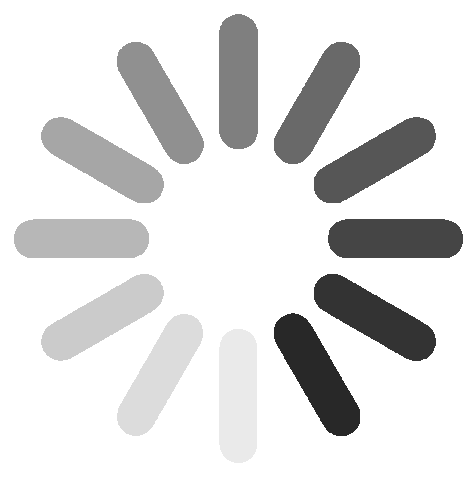

In [11]:
import datamapplot
import umap


X_viz = np.hstack([
    normalize(np.nan_to_num(sage_real_no_host_by_seed[seed]))
    for seed in EXPERIMENT_SEEDS
])
anchor_idx = int(malicious_sessions[0])

X_unit = normalize(np.nan_to_num(X_viz))
anchor_similarity = X_unit @ X_unit[anchor_idx]
ranking = np.argsort(anchor_similarity)[::-1]
ranking = ranking[ranking != anchor_idx]
top100 = set(ranking[:100].tolist())

map_labels = np.full(len(y_eval), "benign", dtype=object)
map_labels[y_eval == "malicious"] = "other malicious"
for idx in top100:
    map_labels[idx] = "retrieved malicious" if y_eval[idx] == "malicious" else "retrieved benign"
map_labels[anchor_idx] = "anchor"

embedding_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.05,
    random_state=SEED,
).fit_transform(X_viz)

hover_text = [
    f"session={idx}<br>label={y_eval[idx]}<br>anchor_similarity={anchor_similarity[idx]:.3f}"
    for idx in range(len(y_eval))
]

datamapplot.create_interactive_plot(
    embedding_2d,
    map_labels,
    hover_text=hover_text,
    title="One-Anchor Retrieval in No-Host HeteroSAGE Space",
    sub_title="Three-seed consensus; gold anchor; top-100 queue colored by retrieval outcome",
    label_color_map={
        "benign": "#d9d9d9",
        "retrieved benign": "#4c78a8",
        "other malicious": "#f2a65a",
        "retrieved malicious": "#d62728",
        "anchor": "#7b2cbf",
    },
)


### Interactive Steering Widget

Choose a confirmed malicious anchor and vary the analyst review budget. The map remains fixed; only the direction supplied by the anchor and the resulting retrieval queue change.


In [12]:
import ipywidgets as widgets
from IPython.display import HTML, clear_output


def session_name(session_idx):
    rows = process_df.iloc[sessions[session_idx]]
    processes = rows["process_name"].fillna("unknown").astype(str).value_counts().head(2).index
    host = rows["hostname"].dropna().astype(str).value_counts()
    host = host.index[0] if len(host) else "unknown host"
    return f"Session {session_idx} | {', '.join(processes)} | {host}"


anchor_picker = widgets.Dropdown(
    options=[(session_name(int(idx)), int(idx)) for idx in malicious_sessions],
    value=int(malicious_sessions[0]),
    description="Anchor",
    layout=widgets.Layout(width="680px"),
    style={"description_width": "65px"},
)
budget_slider = widgets.IntSlider(
    value=100, min=25, max=300, step=25,
    description="Budget", continuous_update=False,
    layout=widgets.Layout(width="460px"),
    style={"description_width": "65px"},
)
show_gold = widgets.ToggleButton(
    value=True, description="Show evaluation labels", icon="eye",
    layout=widgets.Layout(width="210px"),
)
metric_card = widgets.HTML()
map_output = widgets.Output(layout=widgets.Layout(width="72%"))
queue_output = widgets.Output(layout=widgets.Layout(width="28%", max_height="800px", overflow_y="auto"))


def render_live_datamap(anchor_idx, budget, reveal_gold):
    similarity = X_unit @ X_unit[anchor_idx]
    order = np.argsort(similarity)[::-1]
    order = order[order != anchor_idx]
    retrieved = order[:budget]
    retrieved_set = set(retrieved.tolist())

    retrieved_malicious = retrieved[y_eval[retrieved] == "malicious"]
    recall = len(retrieved_malicious) / (len(malicious_sessions) - 1)
    precision = len(retrieved_malicious) / budget
    if reveal_gold:
        metric_card.value = (
            f"<div style='padding:10px 14px;border-radius:9px;background:#f5f3ff;"
            f"border:1px solid #d8ccff;font-family:system-ui'>"
            f"<b>{len(retrieved_malicious)}/{len(malicious_sessions) - 1} hits</b> &nbsp;|&nbsp; "
            f"recall <b>{recall:.1%}</b> &nbsp;|&nbsp; precision <b>{precision:.1%}</b></div>"
        )
    else:
        metric_card.value = "<div style='padding:11px;color:#666'>Gold labels hidden: analyst view</div>"

    live_labels = np.full(len(y_eval), "telemetry background", dtype=object)
    if reveal_gold:
        live_labels[y_eval == "malicious"] = "malicious outside queue"
        for idx in retrieved_set:
            live_labels[idx] = "retrieved malicious" if y_eval[idx] == "malicious" else "retrieved benign"
    else:
        live_labels[retrieved] = "retrieval queue"
    live_labels[anchor_idx] = "confirmed anchor"

    hover = []
    for idx in range(len(y_eval)):
        rows = process_df.iloc[sessions[idx]]
        names = ", ".join(rows["process_name"].fillna("unknown").astype(str).value_counts().head(3).index)
        host = rows["hostname"].dropna().astype(str).value_counts()
        host = host.index[0] if len(host) else "unknown"
        gold = y_eval[idx] if reveal_gold else "hidden"
        hover.append(
            f"session={idx}<br>similarity={similarity[idx]:.3f}<br>"
            f"processes={names}<br>host={host}<br>events={len(sessions[idx])}<br>gold={gold}"
        )

    color_map = {
        "telemetry background": "#d4d4d8",
        "retrieval queue": "#4c78a8",
        "retrieved benign": "#4c78a8",
        "malicious outside queue": "#f2a65a",
        "retrieved malicious": "#d62728",
        "confirmed anchor": "#7b2cbf",
    }
    with map_output:
        clear_output(wait=True)
        live_plot = datamapplot.create_interactive_plot(
            embedding_2d,
            live_labels,
            hover_text=hover,
            label_color_map=color_map,
            title=f"Steering from session {anchor_idx}",
            sub_title=f"Three-seed consensus | top-{budget} behavioral matches | zoom, pan, search, and hover",
        )
        display(live_plot)

    with queue_output:
        clear_output(wait=True)
        queue_rows = []
        for rank, idx in enumerate(retrieved[:20], 1):
            rows = process_df.iloc[sessions[idx]]
            processes = ", ".join(rows["process_name"].fillna("unknown").astype(str).value_counts().head(2).index)
            queue_rows.append({
                "rank": rank, "session": int(idx), "similarity": round(float(similarity[idx]), 3),
                "gold": y_eval[idx] if reveal_gold else "hidden", "processes": processes,
            })
        display(HTML("<h4 style='font-family:system-ui'>Top investigation matches</h4>"))
        display(pd.DataFrame(queue_rows))


def update_live_map(change=None):
    render_live_datamap(anchor_picker.value, budget_slider.value, show_gold.value)


for control in (anchor_picker, budget_slider, show_gold):
    control.observe(update_live_map, names="value")

header = widgets.HTML(
    "<div style='font-family:system-ui'><b style='font-size:20px'>Live behavioral steering</b><br>"
    "<span style='color:#666'>Select a confirmed incident; the interactive DataMap becomes its retrieval surface.</span></div>"
)
controls = widgets.VBox([
    anchor_picker,
    widgets.HBox([budget_slider, show_gold, metric_card], layout=widgets.Layout(gap="14px", align_items="center")),
])
workspace = widgets.HBox([map_output, queue_output], layout=widgets.Layout(width="100%", gap="12px"))
display(widgets.VBox([header, controls, workspace], layout=widgets.Layout(width="100%")))
update_live_map()


### Presentation Animation

Exports a fixed-map steering progression as GIF and MP4. The anchor is selected by a declared median recall@100 rule across all malicious anchors, rather than by choosing the best-looking example.


In [13]:
from pathlib import Path
import shutil
from matplotlib import pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation, PillowWriter


animation_dir = Path("artifacts/presentation")
animation_dir.mkdir(parents=True, exist_ok=True)
gif_path = animation_dir / "steering_progression.gif"
mp4_path = animation_dir / "steering_progression.mp4"

# Representative anchor: recall@100 closest to the median over all possible anchors.
anchor_candidates = []
for candidate in malicious_sessions:
    candidate_scores = X_unit @ X_unit[candidate]
    candidate_order = np.argsort(candidate_scores)[::-1]
    candidate_order = candidate_order[candidate_order != candidate]
    recall_100 = np.sum(y_eval[candidate_order[:100]] == "malicious") / (len(malicious_sessions) - 1)
    anchor_candidates.append((int(candidate), float(recall_100)))

median_recall = float(np.median([value for _, value in anchor_candidates]))
animation_anchor, anchor_recall_100 = min(
    anchor_candidates,
    key=lambda item: (abs(item[1] - median_recall), item[0]),
)
animation_similarity = X_unit @ X_unit[animation_anchor]
animation_order = np.argsort(animation_similarity)[::-1]
animation_order = animation_order[animation_order != animation_anchor]

# Ease from an empty queue to 200 reviewed sessions, with pauses at both ends.
progress = np.linspace(0, 1, 48)
eased = 3 * progress**2 - 2 * progress**3
budgets = np.r_[np.zeros(10), np.rint(200 * eased), np.full(18, 200)].astype(int)

anchor_rows = process_df.iloc[sessions[animation_anchor]]
anchor_processes = ", ".join(
    anchor_rows["process_name"].fillna("unknown").astype(str).value_counts().head(3).index
)
anchor_hosts = anchor_rows["hostname"].dropna().astype(str).value_counts()
anchor_host = anchor_hosts.index[0] if len(anchor_hosts) else "unknown host"

fig, ax = plt.subplots(figsize=(12.8, 7.2), facecolor="#0f1220")
ax.set_facecolor("#0f1220")
ax.scatter(*embedding_2d.T, s=8, c="#7d8499", alpha=0.20, linewidths=0)
unrecovered = ax.scatter([], [], s=50, c="#f2a65a", alpha=0.88,
                         edgecolors="#0f1220", linewidths=0.6, label="malicious not yet retrieved")
retrieved_benign = ax.scatter([], [], s=30, c="#4c9be8", alpha=0.82,
                              edgecolors="white", linewidths=0.25, label="retrieved benign")
retrieved_malicious = ax.scatter([], [], s=92, c="#ff3b4f", alpha=1,
                                 edgecolors="white", linewidths=0.9, label="retrieved malicious")
ax.scatter(*embedding_2d[[animation_anchor]].T, s=310, c="#b56cff", marker="*",
           edgecolors="white", linewidths=1.4, label="confirmed anchor", zorder=20)

title = ax.text(0.03, 0.95, "", transform=ax.transAxes, color="white",
                fontsize=22, weight="bold", va="top")
subtitle = ax.text(
    0.03, 0.885,
    f"Anchor {animation_anchor}  |  {anchor_processes}  |  {anchor_host}",
    transform=ax.transAxes, color="#c8ccda", fontsize=11, va="top",
)
metrics = ax.text(0.03, 0.08, "", transform=ax.transAxes, color="white", fontsize=14,
                  bbox=dict(boxstyle="round,pad=0.55", facecolor="#20263a", edgecolor="#4a5270", alpha=0.95))
progress_bg = plt.Rectangle((0.03, 0.035), 0.55, 0.012, transform=ax.transAxes,
                            color="#30364a", clip_on=False)
progress_fg = plt.Rectangle((0.03, 0.035), 0, 0.012, transform=ax.transAxes,
                            color="#b56cff", clip_on=False)
ax.add_patch(progress_bg)
ax.add_patch(progress_fg)
ax.legend(loc="upper right", facecolor="#171b2b", edgecolor="#3c435c",
          labelcolor="white", framealpha=0.95, fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)


def animate_steering(frame):
    budget = int(budgets[frame])
    retrieved = animation_order[:budget]
    hits = retrieved[y_eval[retrieved] == "malicious"]
    false_positives = retrieved[y_eval[retrieved] != "malicious"]
    remaining = malicious_sessions[
        ~np.isin(malicious_sessions, np.r_[hits, animation_anchor])
    ]
    unrecovered.set_offsets(embedding_2d[remaining])
    retrieved_benign.set_offsets(embedding_2d[false_positives])
    retrieved_malicious.set_offsets(embedding_2d[hits])

    recall = len(hits) / (len(malicious_sessions) - 1)
    precision = len(hits) / budget if budget else 0
    title.set_text("One confirmed incident steers the search" if budget else "Start with one confirmed incident")
    metrics.set_text(
        f"REVIEWED  {budget:>3}     HITS  {len(hits):>2}/{len(malicious_sessions) - 1}     "
        f"RECALL  {recall:>5.1%}     PRECISION  {precision:>5.1%}"
    )
    progress_fg.set_width(0.55 * budget / 200)
    return unrecovered, retrieved_benign, retrieved_malicious, title, metrics, progress_fg


animation = FuncAnimation(fig, animate_steering, frames=len(budgets), interval=80, blit=False)
animation.save(gif_path, writer=PillowWriter(fps=12), dpi=105)
if shutil.which("ffmpeg"):
    animation.save(
        mp4_path,
        writer=FFMpegWriter(fps=12, codec="libx264", bitrate=4500,
                           extra_args=["-pix_fmt", "yuv420p"]),
        dpi=130,
    )
    mp4_message = f"MP4: {mp4_path.resolve()}"
else:
    mp4_message = "MP4 skipped: ffmpeg is not installed; the GIF is complete."
plt.close(fig)

print(f"Representative anchor: {animation_anchor} (recall@100={anchor_recall_100:.1%}; median={median_recall:.1%})")
print(f"GIF: {gif_path.resolve()}")
print(mp4_message)
display(HTML(f"<img src='{gif_path.as_posix()}' style='max-width:100%;border-radius:10px'>"))


Representative anchor: 189 (recall@100=66.7%; median=66.7%)
GIF: /Users/mekael/Desktop/STAMP/Cyber Telemetry/artifacts/presentation/steering_progression.gif
MP4: /Users/mekael/Desktop/STAMP/Cyber Telemetry/artifacts/presentation/steering_progression.mp4


## Result and Defensible Claim

The bounded construction produced 3,131 sessions from 100,000 processes, with no session longer than 30 minutes or larger than 213 processes. Nineteen sessions contain red-team activity.

**Primary grouping result:** removing the dominant same-host relation improved real-edge SAGE separation to `0.195 +/- 0.019`, versus `0.052 +/- 0.023` for its matched shuffled-edge control. The full real graph reached `0.176 +/- 0.011`. This shows the grouping benefit is not explained by the same-host relation; that dense relation was slightly diluting the useful topology.

**Unsupervised review result:** node statistics remain the better global outlier detector, recovering `73.7%` of malicious sessions in the top 10% by distance. The graph embedding's distinct strength is neighborhood coherence rather than global outlier ranking.

**Few-shot steering result:** with one confirmed malicious session as an anchor, real-edge SAGE retrieved the remaining malicious sessions with AP `0.1396 +/- 0.0917` and recall@100 `0.4659 +/- 0.2624`. Raw node statistics reached `0.0660 / 0.2719`; shuffled-edge SAGE reached `0.0308 / 0.1121`; random ranking is `0.0058 / 0.0319`. Paired one-sided Wilcoxon tests over all 19 possible anchors give `p < 0.0005` against both controls for AP and recall@100.

The defensible conclusion is therefore: **self-supervised relational learning creates a malicious-session geometry that is weak for unsupervised outlier ranking but strongly amplifies a single analyst-confirmed example into retrieval of related malicious activity.**

Current limitations are the 19 malicious sessions, one ACME time slice, and likely behavioral similarity within the red-team campaign. This is a few-shot triage result, not yet a cross-dataset or zero-shot generalization claim.


## Next Validation

- Freeze this architecture and repeat the same grouping and one-anchor protocol on a chronological holdout and a second telemetry dataset.
- Add agentic edge proposals only if they beat the same real-vs-shuffled controls and improve held-out one-anchor retrieval.


## Guided Discovery to Steering

The steering experiment assumes that an analyst already has a confirmed anchor. This final experiment closes that gap without using labels for ranking:

1. Raw node statistics provide an unsupervised anomaly score.
2. A candidate region contains sessions that repeatedly appear together in at least two of the three real-SAGE neighborhoods.
3. Regions are ranked by the mean anomaly percentile of their three strongest sessions, requiring multiple pieces of suspicious evidence rather than one isolated outlier.
4. The analyst reviews the highest-ranked region until one session is confirmed, then the existing cosine steering retrieves related activity.

Gold labels are used only to simulate confirmation and evaluate review cost. The same protocol is run with shuffled graph geometry and raw features as controls.

**Exploratory-status note:** the 40-neighbor / top-three-evidence rule was selected after a small diagnostic sweep on this slice. The result is a strong workflow demonstration, but these settings must now be frozen and tested on a chronological holdout before the discovery improvement is treated as confirmatory.


In [14]:
DISCOVERY_K = 40
DISCOVERY_EVIDENCE_POINTS = 3
MAX_REGION_OVERLAP = 0.35
STEERING_BUDGET = 100


def percentile_rank(values):
    return pd.Series(np.asarray(values)).rank(method="average", pct=True).to_numpy(float)


def stable_regions(embeddings_by_seed, k=DISCOVERY_K):
    views = [np.asarray(embeddings_by_seed[seed], dtype=np.float32) for seed in EXPERIMENT_SEEDS]
    neighbors = []
    for view in views:
        _, idx = cKDTree(view).query(view, k=min(k + 1, len(view)), workers=-1)
        neighbors.append(idx[:, 1:])

    regions = []
    stability = np.zeros(len(views[0]), dtype=float)
    for center in range(len(views[0])):
        seed_sets = [set(idx[center].tolist()) | {center} for idx in neighbors]
        counts = {}
        for members in seed_sets:
            for member in members:
                counts[member] = counts.get(member, 0) + 1
        regions.append(np.asarray(sorted(member for member, count in counts.items() if count >= 2)))

        pairwise_jaccard = []
        for left, right in combinations(seed_sets, 2):
            pairwise_jaccard.append(len(left & right) / max(1, len(left | right)))
        stability[center] = np.mean(pairwise_jaccard)
    return regions, stability


def rank_regions(embeddings_by_seed, anomaly_percentile):
    regions, stability = stable_regions(embeddings_by_seed)
    region_score = np.asarray([
        np.sort(anomaly_percentile[members])[-min(DISCOVERY_EVIDENCE_POINTS, len(members)):].mean()
        for members in regions
    ])

    ranked = []
    for center in np.argsort(region_score)[::-1]:
        members = set(regions[center].tolist())
        if any(
            len(members & previous) / max(1, len(members | previous)) > MAX_REGION_OVERLAP
            for _, previous in ranked
        ):
            continue
        ranked.append((int(center), members))
    return ranked, region_score, stability


def simulate_region_confirmation(embeddings_by_seed, anomaly_percentile):
    ranked, region_score, stability = rank_regions(embeddings_by_seed, anomaly_percentile)
    reviewed = []
    for region_rank, (center, member_set) in enumerate(ranked, 1):
        members = np.asarray(sorted(member_set), dtype=int)
        review_order = members[np.argsort(anomaly_percentile[members])[::-1]]
        for session_idx in review_order:
            reviewed.append(int(session_idx))
            if y_eval[session_idx] == "malicious":
                return {
                    "anchor": int(session_idx),
                    "reviewed": reviewed,
                    "region_rank": region_rank,
                    "region_center": center,
                    "region_members": members,
                    "region_score": float(region_score[center]),
                    "region_stability": float(stability[center]),
                }
    raise RuntimeError("No malicious session was found in the ranked regions.")


def consensus_similarity(embeddings_by_seed, anchor_idx):
    similarities = []
    for seed in EXPERIMENT_SEEDS:
        unit = normalize(np.nan_to_num(embeddings_by_seed[seed]))
        similarities.append(unit @ unit[anchor_idx])
    return np.mean(similarities, axis=0)


def steering_queue(similarity, reviewed, budget=STEERING_BUDGET):
    blocked = set(reviewed)
    order = [idx for idx in np.argsort(similarity)[::-1] if idx not in blocked]
    return np.asarray(order[:budget], dtype=int)


raw_anomaly, _ = knn_scores_and_neighbor_rate(X_node_stats, labels_eval)
anomaly_percentile = percentile_rank(raw_anomaly)
raw_order = np.argsort(anomaly_percentile)[::-1]
raw_anchor_position = int(np.flatnonzero(y_eval[raw_order] == "malicious")[0] + 1)

real_discovery = simulate_region_confirmation(sage_real_no_host_by_seed, anomaly_percentile)
shuffled_discovery = simulate_region_confirmation(sage_shuffled_no_host_by_seed, anomaly_percentile)
discovered_anchor = real_discovery["anchor"]

real_similarity = consensus_similarity(sage_real_no_host_by_seed, discovered_anchor)
shuffled_similarity = consensus_similarity(sage_shuffled_no_host_by_seed, discovered_anchor)
node_unit = normalize(np.nan_to_num(X_node_stats))
node_similarity = node_unit @ node_unit[discovered_anchor]

real_queue = steering_queue(real_similarity, real_discovery["reviewed"])
shuffled_queue = steering_queue(shuffled_similarity, real_discovery["reviewed"])
node_queue = steering_queue(node_similarity, real_discovery["reviewed"])

real_hits = int(np.sum(y_eval[real_queue] == "malicious"))
shuffled_hits = int(np.sum(y_eval[shuffled_queue] == "malicious"))
node_hits = int(np.sum(y_eval[node_queue] == "malicious"))

discovery_summary = pd.DataFrame([
    {"discovery method": "raw anomaly queue", "reviews to first anchor": raw_anchor_position},
    {"discovery method": "shuffled-graph regions", "reviews to first anchor": len(shuffled_discovery["reviewed"])},
    {"discovery method": "real-graph stable regions", "reviews to first anchor": len(real_discovery["reviewed"])},
])
steering_handoff = pd.DataFrame([
    {"steering representation": "node statistics", "malicious in next 100": node_hits},
    {"steering representation": "shuffled-graph consensus", "malicious in next 100": shuffled_hits},
    {"steering representation": "real-graph consensus", "malicious in next 100": real_hits},
])

print(
    f"End-to-end real graph: {len(real_discovery['reviewed'])} reviews to confirm anchor "
    f"{discovered_anchor}, then {real_hits}/{len(malicious_sessions) - 1} remaining malicious sessions in the next "
    f"{STEERING_BUDGET} reviews."
)
display(discovery_summary)
display(steering_handoff)


End-to-end real graph: 26 reviews to confirm anchor 3060, then 10/18 remaining malicious sessions in the next 100 reviews.


,discovery method,reviews to first anchor
0,raw anomaly queue,86
1,shuffled-graph regions,67
2,real-graph stable regions,26


,steering representation,malicious in next 100
0,node statistics,3
1,shuffled-graph consensus,1
2,real-graph consensus,10


### Presentation DataMap: Discovery → Confirmation → Steering

This fixed-map evaluation view tells the complete workflow in one frame. Gold labels affect only the final colors—not region ranking, anchor discovery, or retrieval order. The interactive HTML is also exported to `artifacts/presentation/discovery_to_steering_datamap.html`.


Interactive presentation map: /Users/mekael/Desktop/STAMP/Cyber Telemetry/artifacts/presentation/discovery_to_steering_datamap.html


<InteractiveFigure width=100% height=820>
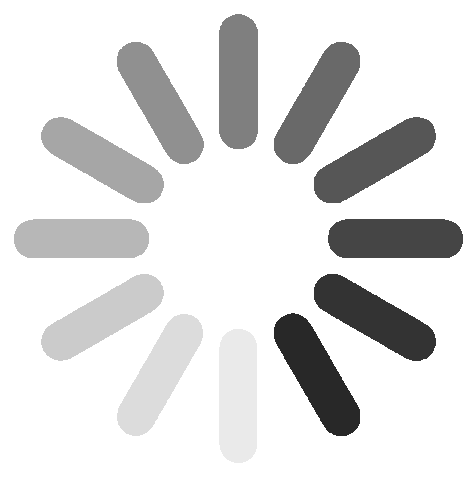

In [15]:
from pathlib import Path
import datamapplot
import umap

if "embedding_2d" not in globals():
    X_viz = np.hstack([
        normalize(np.nan_to_num(sage_real_no_host_by_seed[seed]))
        for seed in EXPERIMENT_SEEDS
    ])
    embedding_2d = umap.UMAP(
        n_components=2, n_neighbors=15, min_dist=0.05, random_state=SEED
    ).fit_transform(X_viz)

discovery_region = set(real_discovery["region_members"].tolist())
reviewed_before_anchor = set(real_discovery["reviewed"][:-1])
retrieved = set(real_queue.tolist())

presentation_labels = np.full(len(y_eval), "telemetry background", dtype=object)
presentation_labels[y_eval == "malicious"] = "malicious outside queue"
for idx in discovery_region:
    presentation_labels[idx] = "priority discovery region"
for idx in reviewed_before_anchor:
    presentation_labels[idx] = "reviewed before confirmation"
for idx in retrieved:
    presentation_labels[idx] = (
        "retrieved malicious" if y_eval[idx] == "malicious" else "retrieved benign"
    )
presentation_labels[discovered_anchor] = "confirmed anchor"

marker_sizes = np.full(len(y_eval), 2.5)
marker_alpha = np.full(len(y_eval), 0.18)
style = {
    "malicious outside queue": (18, 0.90),
    "priority discovery region": (11, 0.82),
    "reviewed before confirmation": (15, 0.95),
    "retrieved benign": (9, 0.78),
    "retrieved malicious": (30, 1.00),
    "confirmed anchor": (52, 1.00),
}
for label, (size, alpha) in style.items():
    mask = presentation_labels == label
    marker_sizes[mask] = size
    marker_alpha[mask] = alpha

presentation_hover = []
for idx in range(len(y_eval)):
    rows = process_df.iloc[sessions[idx]]
    processes = ", ".join(
        rows["process_name"].fillna("unknown").astype(str).value_counts().head(3).index
    )
    hosts = rows["hostname"].dropna().astype(str).value_counts()
    host = hosts.index[0] if len(hosts) else "unknown"
    presentation_hover.append(
        f"<b>Session {idx}</b><br>stage={presentation_labels[idx]}<br>"
        f"processes={processes}<br>host={host}<br>events={len(sessions[idx])}<br>"
        f"anomaly percentile={anomaly_percentile[idx]:.1%}<br>"
        f"anchor similarity={real_similarity[idx]:.3f}<br>gold={y_eval[idx]}"
    )

discovery_to_steering_plot = datamapplot.create_interactive_plot(
    embedding_2d,
    presentation_labels,
    hover_text=presentation_hover,
    # title="From telemetry background to an investigation direction",
    title="Steering Telemetry Triage with Self-Supervised Graph Geometry",
    sub_title=(
        f"{len(real_discovery['reviewed'])} reviews to first confirmation  •  "
        # f"{real_hits}/{len(malicious_sessions)} related malicious sessions recovered in the next {STEERING_BUDGET}  •  "
        f"{real_hits}/18 related malicious sessions recovered in the next {STEERING_BUDGET}  •  "
        "real typed topology"
    ),
    label_color_map={
        "telemetry background": "#667085",
        "priority discovery region": "#f4c95d",
        "reviewed before confirmation": "#f59e0b",
        "confirmed anchor": "#c084fc",
        "retrieved benign": "#38bdf8",
        "retrieved malicious": "#ff3b4f",
        "malicious outside queue": "#fb923c",
    },
    marker_size_array=marker_sizes,
    marker_alpha_array=marker_alpha,
    noise_label="telemetry background",
    noise_color="#667085",
    darkmode=True,
    height=820,
)

presentation_dir = Path("artifacts/presentation")
presentation_dir.mkdir(parents=True, exist_ok=True)
discovery_map_path = presentation_dir / "discovery_to_steering_datamap.html"
discovery_to_steering_plot.save(discovery_map_path)
print(f"Interactive presentation map: {discovery_map_path.resolve()}")
display(discovery_to_steering_plot)


In [16]:
print(f"Total malicious sessions: {len(malicious_sessions)}")
print(f"Malicious sessions in graph_data: {int(sum(any(graph_data['process'].y[n].item() == 1 for n in s) for s in sessions))}")
print(f"Matches build_summary: {build_summary['malicious_sessions'].iloc[0]}")


Total malicious sessions: 19
Malicious sessions in graph_data: 19
Matches build_summary: 19
